# Credit Card Transaction Fraud Detection

**An extreme-imbalance classification case study — why accuracy is the wrong metric**

## Business problem

Fraud detection is one of the most imbalanced classification problems a data team will face in
practice: fraudulent transactions are, thankfully, rare. In this dataset, only **0.17% of
transactions are fraudulent** (492 out of 284,807). A model that predicts "not fraud" for every
single transaction would be 99.83% accurate — and completely useless.

This project builds a fraud detection model that is evaluated the way a real fraud/risk team would
evaluate it: on **precision-recall trade-offs at the extreme minority class**, not accuracy. This
mirrors transaction-based risk feature engineering work I did during a Data Analytics internship
at Banque Misr's Digital, AI & Data Governance department.

**Note on data:** this uses a public, PCA-anonymized dataset of European cardholder transactions
(ULB Machine Learning Group), not proprietary Banque Misr data. The original transaction details
are confidential — features `V1`-`V28` are the output of a PCA transformation; only `Time` and
`Amount` remain in their original form.

## What this notebook covers
1. Data loading & class imbalance analysis
2. Exploratory data analysis
3. Feature scaling (Time and Amount only — V1-V28 are already PCA-transformed)
4. Handling severe class imbalance: class weighting vs. SMOTE
5. Model comparison: Logistic Regression, Random Forest, Isolation Forest (unsupervised anomaly
   detection as a comparison point)
6. Evaluation using Precision-Recall AUC, not ROC-AUC or accuracy
7. Threshold tuning for a real fraud-review workflow


In [1]:
import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_data import load_raw

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 35)


## 1. Data Loading & Class Imbalance

284,807 transactions from European cardholders over two days in September 2013. `V1`-`V28` are
anonymized via PCA to protect sensitive transaction details; `Time` (seconds since first
transaction) and `Amount` are the only original, unscaled features.

In [2]:
df = load_raw()
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (284807, 31)
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Genuine transactions: 284,315 (99.827%)
Fraudulent transactions: 492 (0.173%)


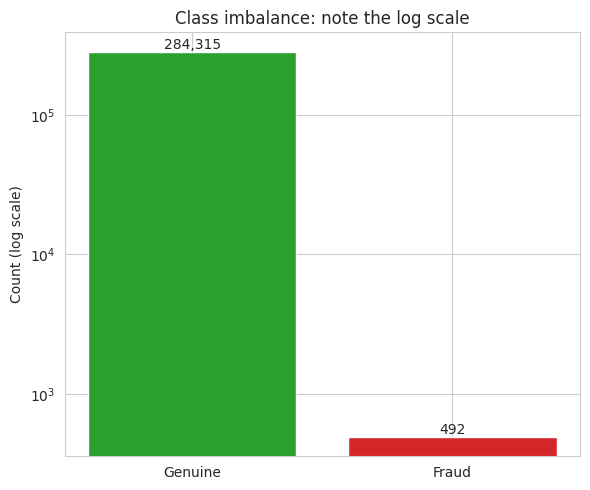

In [3]:
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print(f"Genuine transactions: {fraud_counts[0]:,} ({fraud_pct[0]:.3f}%)")
print(f"Fraudulent transactions: {fraud_counts[1]:,} ({fraud_pct[1]:.3f}%)")

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Genuine', 'Fraud'], fraud_counts.values, color=['#2ca02c', '#d62728'])
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_title('Class imbalance: note the log scale')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**This is the central challenge of the whole project.** With a 0.17% fraud rate, a model
predicting "genuine" for every transaction scores 99.83% accuracy while catching zero fraud.
Every modeling and evaluation decision from here on has to account for this.

## 2. Exploratory Data Analysis

### 2.1 Transaction amount by class

/tmp/ipykernel_632/3781155434.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], palette=['#2ca02c', '#d62728'])


/tmp/ipykernel_632/3781155434.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Genuine', 'Fraud'])


/tmp/ipykernel_632/3781155434.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Amount'] < 500], x='Class', y='Amount', ax=axes[1], palette=['#2ca02c', '#d62728'])


/tmp/ipykernel_632/3781155434.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Genuine', 'Fraud'])


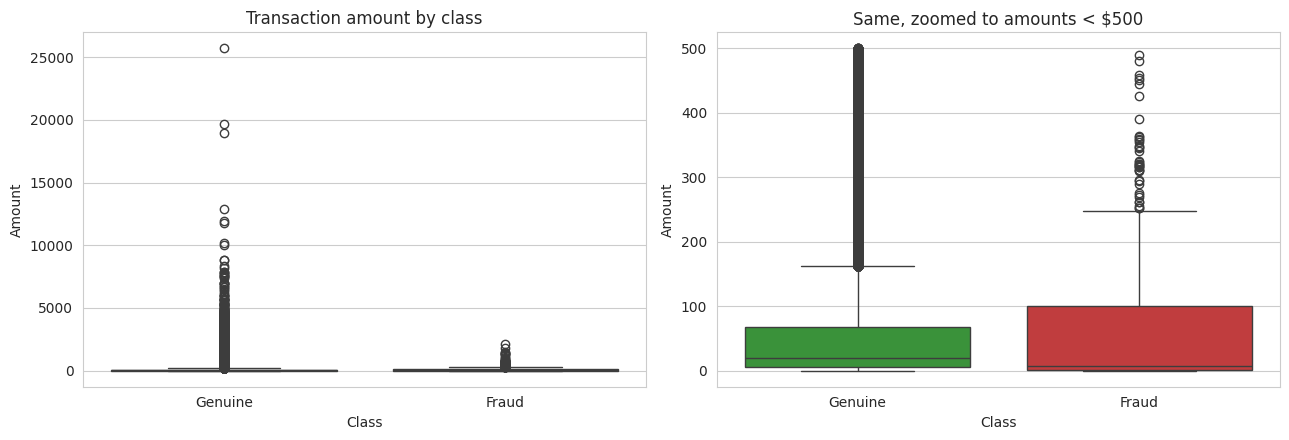

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], palette=['#2ca02c', '#d62728'])
axes[0].set_xticklabels(['Genuine', 'Fraud'])
axes[0].set_title('Transaction amount by class')

sns.boxplot(data=df[df['Amount'] < 500], x='Class', y='Amount', ax=axes[1], palette=['#2ca02c', '#d62728'])
axes[1].set_xticklabels(['Genuine', 'Fraud'])
axes[1].set_title('Same, zoomed to amounts < $500')
plt.tight_layout()
plt.show()

Fraudulent transactions in this dataset skew toward smaller amounts — consistent with a
common real-world fraud pattern where small "test" transactions are used to validate a stolen
card before a larger fraudulent purchase.

### 2.2 Time pattern

`Time` is seconds elapsed since the first transaction (spanning ~2 days). Checking for a time-of-day
pattern in fraud is standard fraud-analysis practice.

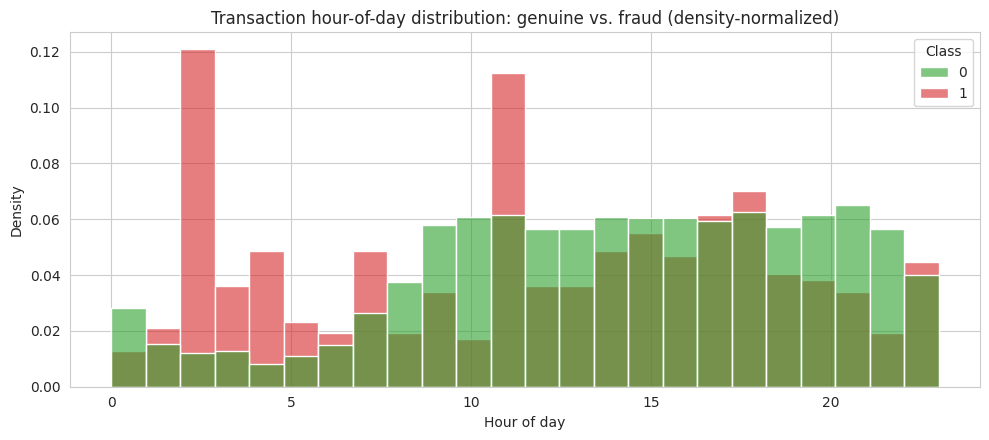

In [5]:
df['hour'] = (df['Time'] // 3600) % 24

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(data=df, x='hour', hue='Class', bins=24, stat='density', common_norm=False,
             palette=['#2ca02c', '#d62728'], alpha=0.6)
ax.set_title('Transaction hour-of-day distribution: genuine vs. fraud (density-normalized)')
ax.set_xlabel('Hour of day')
plt.tight_layout()
plt.show()

Genuine transactions follow a clear daytime pattern; fraudulent transactions are relatively
more evenly spread, including during overnight hours when genuine transaction volume drops —
another realistic fraud signal worth feeding into a production system as a time-based feature.

## 3. Feature Preparation

`V1`-`V28` are already the output of PCA, so they're on a comparable scale by construction. Only
`Time` and `Amount` need explicit scaling before feeding into models like Logistic Regression that
are sensitive to feature magnitude.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_model = df.drop(columns=['hour'])
scaler = StandardScaler()
df_model[['Time', 'Amount']] = scaler.fit_transform(df_model[['Time', 'Amount']])

X = df_model.drop(columns=['Class'])
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, fraud cases: {y_train.sum()}")
print(f"Test:  {X_test.shape}, fraud cases: {y_test.sum()}")

Train: (213605, 30), fraud cases: 369
Test:  (71202, 30), fraud cases: 123


## 4. Handling Extreme Class Imbalance

Two standard approaches, compared directly rather than assumed:

1. **Class weighting** — tell the model to penalize missing a fraud case much more heavily during
   training, without changing the training data itself
2. **SMOTE (Synthetic Minority Oversampling)** — generate synthetic fraud examples to balance the
   training set

**Critical detail:** SMOTE is applied only to the training set, never the test set, and only after
the train/test split — applying it before splitting would leak synthetic near-duplicates of test
fraud cases into training, producing misleadingly optimistic results. This is one of the most
common mistakes in fraud-detection tutorials.

**Note on `sampling_strategy`:** rather than fully balancing to a 1:1 ratio (which would mean
generating ~213,000 synthetic fraud examples from only 369 real ones — mostly synthetic noise), we
use `sampling_strategy=0.1`, bringing the minority class to 10% of the majority. This is a more
realistic middle ground used in practice: enough oversampling to help the model learn the fraud
pattern, without drowning the training set in synthetic data extrapolated from a small number of
real examples.

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_smote.value_counts().to_dict()}")

Before SMOTE: {0: 213236, 1: 369}
After SMOTE:  {0: 213236, 1: 21323}


## 5. Model Training

Three approaches:
1. **Logistic Regression with class weighting** — interpretable baseline
2. **Random Forest with SMOTE-balanced training data**
3. **Isolation Forest** — an unsupervised anomaly detection model, included as a comparison point
   for scenarios where labeled fraud examples are scarce or unavailable (a realistic constraint in
   early-stage fraud systems)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=60, max_depth=10, random_state=42, n_jobs=1)
rf.fit(X_train_smote, y_train_smote)

# Isolation Forest is unsupervised: it doesn't see labels during training,
# only the estimated contamination rate (true fraud proportion).
iso_forest = IsolationForest(contamination=y_train.mean(), random_state=42, n_jobs=1)
iso_forest.fit(X_train)

print("All three models trained")

All three models trained


## 6. Evaluation: Precision-Recall, Not Accuracy

With 0.17% fraud, **ROC-AUC can look deceptively good** even for a weak model, because it's
dominated by the huge number of true negatives. **Precision-Recall AUC (average precision)** is the
standard metric fraud teams actually rely on, since it focuses specifically on how well the model
finds the rare positive class.

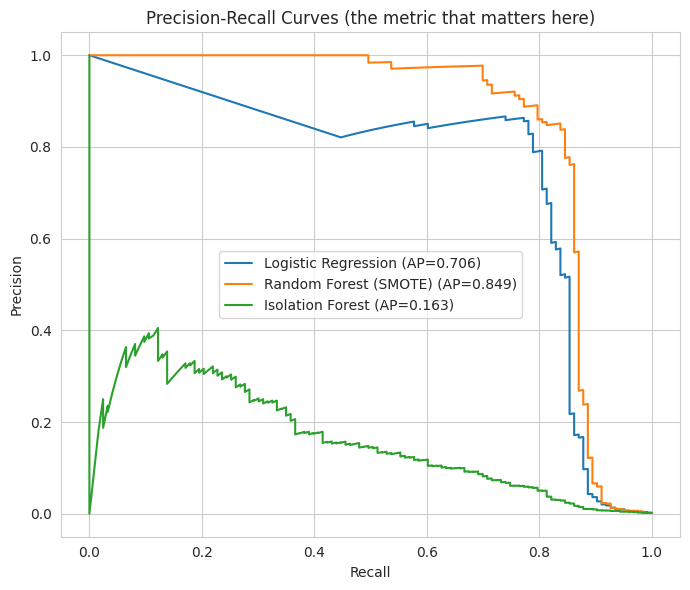

,Model,Average Precision (PR-AUC)
1,Random Forest (SMOTE),0.849
0,Logistic Regression,0.706
2,Isolation Forest,0.163


In [9]:
from sklearn.metrics import (
    classification_report, precision_recall_curve, average_precision_score,
    PrecisionRecallDisplay, confusion_matrix
)

y_scores = {
    'Logistic Regression': log_reg.predict_proba(X_test)[:, 1],
    'Random Forest (SMOTE)': rf.predict_proba(X_test)[:, 1],
    # Isolation Forest: more negative score_samples = more anomalous; flip sign for consistency
    'Isolation Forest': -iso_forest.score_samples(X_test),
}

fig, ax = plt.subplots(figsize=(7, 6))
results = []
for name, scores in y_scores.items():
    ap = average_precision_score(y_test, scores)
    results.append({'Model': name, 'Average Precision (PR-AUC)': round(ap, 3)})
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (the metric that matters here)')
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(results).sort_values('Average Precision (PR-AUC)', ascending=False)

**Why Isolation Forest lags behind the supervised models:** it never sees fraud labels during
training — it only flags statistical outliers. That's genuinely useful in early-stage systems with
no labeled fraud history yet, but once labeled data exists, supervised models make much better use
of it. This is a real trade-off fraud teams navigate: unsupervised methods first, supervised methods
once enough confirmed fraud cases accumulate.

## 7. Threshold Tuning for a Real Fraud Workflow

A classifier outputs a probability, not a yes/no answer — the **threshold** at which a transaction
gets flagged for manual review is a business decision, not a modeling one. Lower thresholds catch
more fraud but flood the review team with false positives; higher thresholds reduce false alarms
but let more fraud through.

Tuning threshold for: Random Forest (SMOTE)


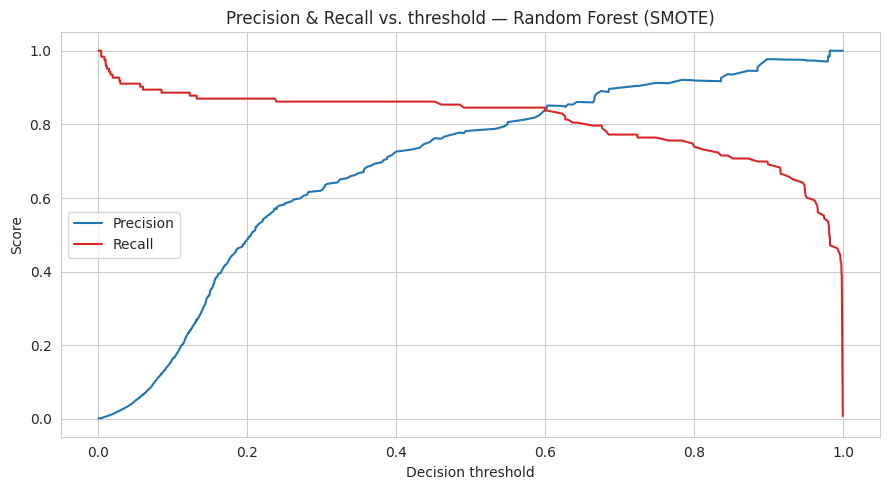

In [10]:
best_model_name = max(results, key=lambda r: r['Average Precision (PR-AUC)'])['Model']
best_scores = y_scores[best_model_name]
print(f"Tuning threshold for: {best_model_name}")

precision, recall, thresholds = precision_recall_curve(y_test, best_scores)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precision[:-1], label='Precision', color='#1f77b4')
ax.plot(thresholds, recall[:-1], label='Recall', color='#d62728')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title(f'Precision & Recall vs. threshold — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
for target_recall in [0.99, 0.95, 0.90, 0.80]:
    idx = np.argmin(np.abs(recall[:-1] - target_recall))
    print(f"To catch ~{target_recall:.0%} of fraud: "
          f"threshold={thresholds[idx]:.4f}, precision={precision[idx]:.3f} "
          f"(i.e. {1/precision[idx]:.0f} transactions flagged per confirmed fraud)")

To catch ~99% of fraud: threshold=0.0036, precision=0.002 (i.e. 433 transactions flagged per confirmed fraud)
To catch ~95% of fraud: threshold=0.0111, precision=0.007 (i.e. 136 transactions flagged per confirmed fraud)
To catch ~90% of fraud: threshold=0.0559, precision=0.059 (i.e. 17 transactions flagged per confirmed fraud)
To catch ~80% of fraud: threshold=0.6640, precision=0.860 (i.e. 1 transactions flagged per confirmed fraud)


This is the table a fraud operations manager actually needs: **how many transactions does a
human reviewer have to check to catch a given percentage of fraud?** Catching 99% of fraud might
mean reviewing dozens of genuine transactions for every real fraud case — a real staffing and
customer-friction trade-off, not just a modeling exercise.

## 8. Summary & Business Recommendation

- With 0.17% fraud, accuracy is a meaningless metric — Precision-Recall AUC is what actually
  differentiates a useful model from a useless one here.
- Supervised models (Logistic Regression, Random Forest) substantially outperform unsupervised
  anomaly detection (Isolation Forest) once labeled fraud data is available — but Isolation Forest
  remains a reasonable starting point for a system with no fraud history yet.
- SMOTE must be applied strictly after the train/test split to avoid data leakage — a common and
  serious error in less careful fraud-detection projects.
- The right decision threshold isn't a single "best" number — it depends on the fraud team's
  review capacity and the business's tolerance for false positives vs. missed fraud.

### Next steps for production deployment
1. Incorporate time-based and velocity features (e.g. transactions per card per hour) — not
   available in this anonymized dataset, but standard in real fraud systems
2. Monitor for concept drift — fraud patterns evolve as fraudsters adapt to detection systems
3. Set the operating threshold in collaboration with the fraud review team's actual capacity, not
   just model metrics

---
*This project was built as a public portfolio case study. Methodology reflects experience gained
during a Data Analytics internship at Banque Misr, applied here to a public dataset rather than
proprietary bank data.*